# AI-Based Predictive Maintenance Using Machine Learning

## Project Objective
The objective of this project is to develop a machine learning
model that can predict machine failure using industrial machine-condition data.
The project uses features such as air temperature, process temperature, rotational speed, torque,
and tool wear to identify failure patterns and support early maintenance decisions.

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Load AI4I 2020 Predictive Maintenance Dataset from UCI
ai4i = fetch_ucirepo(id=601)

# Features and target
X = ai4i.data.features
y = ai4i.data.targets

# Combine features and target into one dataframe
df = pd.concat([X, y], axis=1)

# Show first 5 rows
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# Check dataset shape
df.shape

(10000, 12)

In [9]:
# Check column names
df.columns

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [10]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [11]:
# Check missing values
df.isnull().sum()

,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Machine failure,0
TWF,0
HDF,0
PWF,0


In [12]:
# Check target columns
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [13]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [14]:
df['Machine failure'].value_counts(normalize=True) * 100

,proportion
Machine failure,
0,96.61
1,3.39


## Dataset Understanding

The dataset contains machine operating conditions and failure information. The target variable is Machine failure, where 0 means no failure and 1 means failure. Since machine failure cases are much fewer than normal cases, this is an imbalanced classification problem.

In [15]:
df.shape

(10000, 12)

In [16]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [17]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

The dataset was checked for missing values and duplicate records. No major cleaning was required because the dataset is already structured and suitable for machine learning analysis.

In [18]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


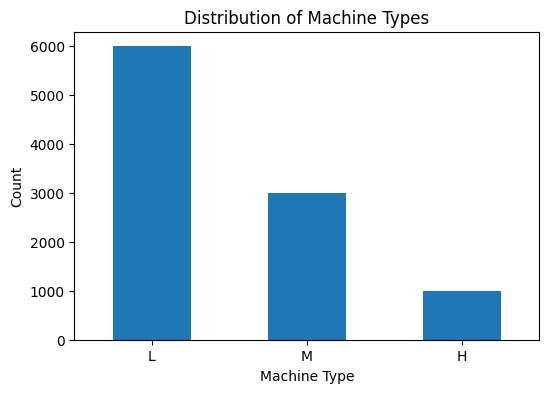

In [19]:
plt.figure(figsize=(6,4))
df['Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [20]:
failure_by_type = df.groupby('Type')['Machine failure'].sum()
failure_by_type

,Machine failure
Type,
H,21
L,235
M,83


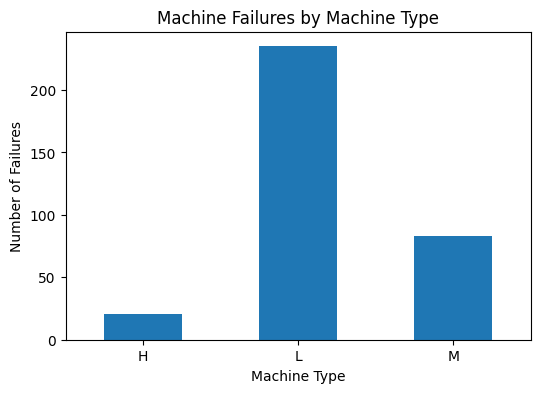

In [21]:
plt.figure(figsize=(6,4))
failure_by_type.plot(kind='bar')
plt.title('Machine Failures by Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Number of Failures')
plt.xticks(rotation=0)
plt.show()

In [22]:
df.columns
df.describe()
df['Machine failure'].value_counts()
failure_by_type

,Machine failure
Type,
H,21
L,235
M,83


In [24]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nStatistical summary:")
display(df.describe())

print("\nMachine failure count:")
print(df['Machine failure'].value_counts())

print("\nMachine failures by machine type:")
print(failure_by_type)

Column names:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset shape:
(10000, 12)

Statistical summary:


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



Machine failure count:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failures by machine type:
Type
H     21
L    235
M     83
Name: Machine failure, dtype: int64


In [25]:
failure_rate_by_type = df.groupby('Type')['Machine failure'].mean() * 100
failure_rate_by_type

,Machine failure
Type,
H,2.093719
L,3.916667
M,2.769436


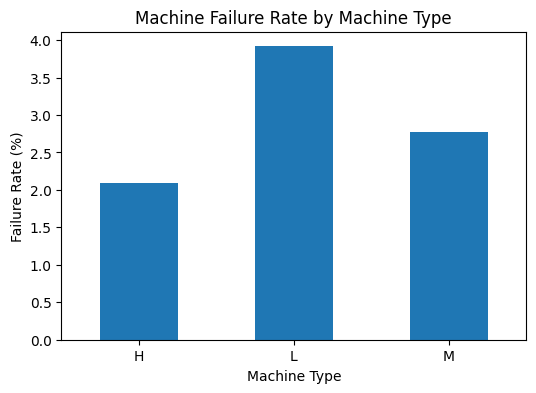

In [26]:
plt.figure(figsize=(6,4))
failure_rate_by_type.plot(kind='bar')
plt.title('Machine Failure Rate by Machine Type')
plt.xlabel('Machine Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=0)
plt.show()

## Failure Rate by Machine Type

The number of failures alone does not give the full picture because some machine types may appear more frequently in the dataset. Therefore, the failure rate was calculated for each machine type to compare the percentage of failures across machine categories.

In [27]:
failure_rate_by_type

,Machine failure
Type,
H,2.093719
L,3.916667
M,2.769436


### Insight: Failure Rate by Machine Type

Type L machines show the highest failure rate at around 3.92%, followed by Type M at 2.77% and Type H at 2.09%. This suggests that machine type may have some relationship with failure risk, although other operating conditions such as torque, rotational speed, temperature, and tool wear should also be analyzed.

In [30]:
df.columns.tolist()

['Type',
 'Air temperature',
 'Process temperature',
 'Rotational speed',
 'Torque',
 'Tool wear',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [31]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Automatically select numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns that should not be used for this analysis
columns_to_remove = ['UDI', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

numerical_features = [col for col in numerical_features if col not in columns_to_remove]

numerical_features

['Air temperature',
 'Process temperature',
 'Rotational speed',
 'Torque',
 'Tool wear']

In [32]:
df.groupby('Machine failure')[numerical_features].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


### Insight: Numerical Feature Analysis

The average values show that failed machines have higher torque and higher tool wear compared to non-failed machines. Failed machines also have slightly lower rotational speed. This suggests that torque, tool wear, and rotational speed may be important indicators for predicting machine failure.

<Figure size 600x400 with 0 Axes>

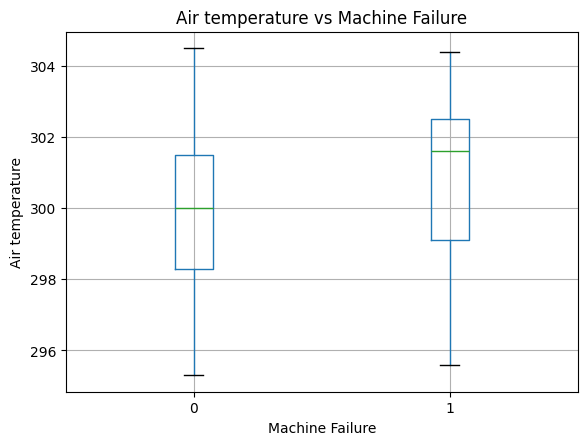

<Figure size 600x400 with 0 Axes>

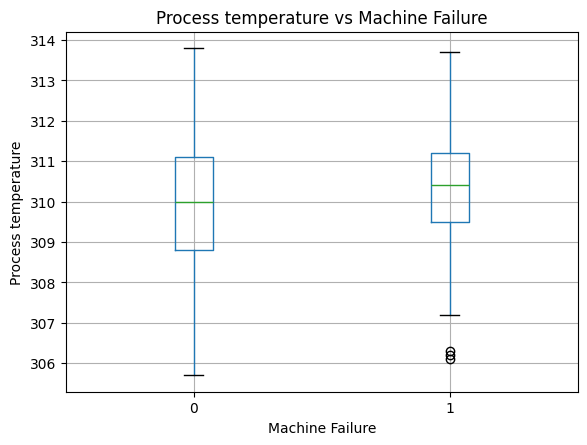

<Figure size 600x400 with 0 Axes>

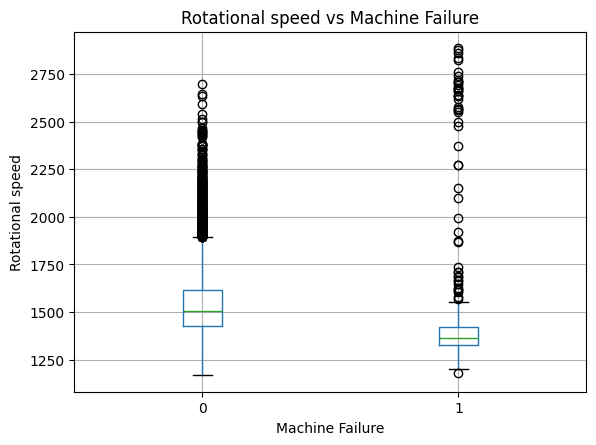

<Figure size 600x400 with 0 Axes>

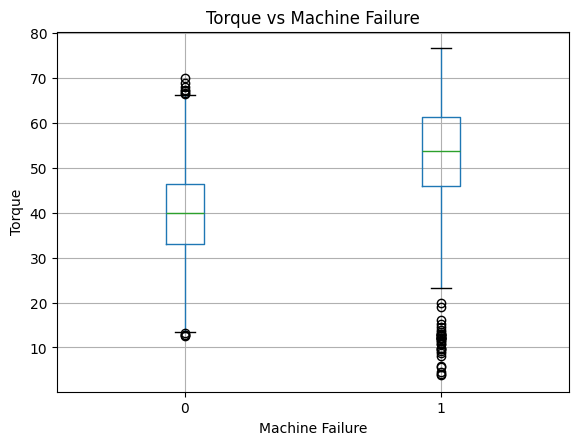

<Figure size 600x400 with 0 Axes>

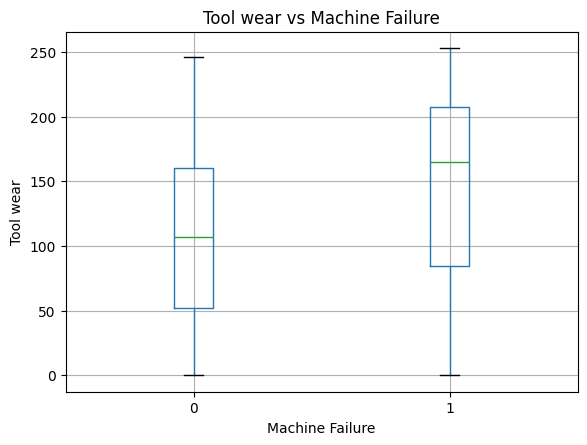

In [33]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by='Machine failure')
    plt.title(f'{col} vs Machine Failure')
    plt.suptitle('')
    plt.xlabel('Machine Failure')
    plt.ylabel(col)
    plt.show()

In [34]:
numerical_features
df.groupby('Machine failure')[numerical_features].mean()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [36]:
correlation_with_failure = df[numerical_features + ['Machine failure']].corr()['Machine failure'].sort_values(ascending=False)
correlation_with_failure

,Machine failure
Machine failure,1.000000
Torque,0.191321
Tool wear,0.105448
Air temperature,0.082556
Process temperature,0.035946
Rotational speed,-0.044188


## Correlation Analysis

Correlation analysis was used to understand the relationship between numerical machine-condition features and machine failure. A positive correlation means that the feature tends to increase when failure occurs, while a negative correlation means that the feature tends to decrease when failure occurs.

In [37]:
# Create new engineered features

df['Temperature difference'] = df['Process temperature'] - df['Air temperature']

df['Power indicator'] = df['Torque'] * df['Rotational speed']

df['Torque per speed'] = df['Torque'] / df['Rotational speed']

df[['Air temperature', 'Process temperature', 'Temperature difference',
    'Torque', 'Rotational speed', 'Power indicator', 'Torque per speed']].head()

,Air temperature,Process temperature,Temperature difference,Torque,Rotational speed,Power indicator,Torque per speed
0,298.1,308.6,10.5,42.8,1551,66382.8,0.027595
1,298.2,308.7,10.5,46.3,1408,65190.4,0.032884
2,298.1,308.5,10.4,49.4,1498,74001.2,0.032977
3,298.2,308.6,10.4,39.5,1433,56603.5,0.027565
4,298.2,308.7,10.5,40.0,1408,56320.0,0.028409


## Feature Engineering

New features were created to improve the predictive power of the dataset. Temperature difference represents the gap between process and air temperature. Power indicator combines torque and rotational speed to approximate machine load. Torque per speed represents load intensity relative to rotational speed.

In [38]:
engineered_features = ['Temperature difference', 'Power indicator', 'Torque per speed']

df.groupby('Machine failure')[engineered_features].mean()

,Temperature difference,Power indicator,Torque per speed
Machine failure,,,
0,10.021571,59631.036446,0.026553
1,9.403835,69545.803245,0.036638


In [39]:
correlation_with_failure
df.groupby('Machine failure')[engineered_features].mean()

,Temperature difference,Power indicator,Torque per speed
Machine failure,,,
0,10.021571,59631.036446,0.026553
1,9.403835,69545.803245,0.036638


In [40]:
print("Correlation with Machine Failure:")
display(correlation_with_failure)

print("\nEngineered Feature Averages:")
display(df.groupby('Machine failure')[engineered_features].mean())

Correlation with Machine Failure:


,Machine failure
Machine failure,1.000000
Torque,0.191321
Tool wear,0.105448
Air temperature,0.082556
Process temperature,0.035946
Rotational speed,-0.044188



Engineered Feature Averages:


,Temperature difference,Power indicator,Torque per speed
Machine failure,,,
0,10.021571,59631.036446,0.026553
1,9.403835,69545.803245,0.036638


### Insight: Engineered Features

The engineered features show useful differences between failed and non-failed machines. Failed machines have a higher power indicator and higher torque per speed, suggesting that machines operating under higher load conditions are more likely to fail.

In [42]:
# Define target variable
target = 'Machine failure'

# Columns we should NOT use as input features
drop_columns = [
    'UDI',
    'Product ID',
    'Machine failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

# Drop only the columns that actually exist in the dataframe
existing_drop_columns = [col for col in drop_columns if col in df.columns]

# Create feature data X and target data y
X = df.drop(columns=existing_drop_columns)
y = df[target]

# Convert categorical column 'Type' into numerical columns if it exists
if 'Type' in X.columns:
    X = pd.get_dummies(X, columns=['Type'], drop_first=True)

# Show final input features
X.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Power indicator,Torque per speed,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,66382.8,0.027595,False,True
1,298.2,308.7,1408,46.3,3,10.5,65190.4,0.032884,True,False
2,298.1,308.5,1498,49.4,5,10.4,74001.2,0.032977,True,False
3,298.2,308.6,1433,39.5,7,10.4,56603.5,0.027565,True,False
4,298.2,308.7,1408,40.0,9,10.5,56320.0,0.028409,True,False


In [43]:
print("Final feature columns:")
print(X.columns.tolist())

print("\nShape of X:")
print(X.shape)

print("\nShape of y:")
print(y.shape)

Final feature columns:
['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Temperature difference', 'Power indicator', 'Torque per speed', 'Type_L', 'Type_M']

Shape of X:
(10000, 10)

Shape of y:
(10000,)


## Machine Learning Data Preparation

The target variable is Machine failure. Identifier columns such as UDI and Product ID were removed because they do not provide useful predictive information. Failure-type columns such as TWF, HDF, PWF, OSF, and RNF were also removed to avoid data leakage. The categorical Type column was converted into numerical form using one-hot encoding.

In [44]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (8000, 10)
Testing data shape: (2000, 10)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [45]:
# Scale the data for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
log_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate model
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
[[1657  275]
 [   9   59]]
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [46]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[1929    3]
 [  21   47]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [47]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858,0.176647,0.867647,0.293532
1,Random Forest,0.988,0.940000,0.691176,0.796610


## Model Evaluation

The models were evaluated using accuracy, precision, recall, and F1-score. In predictive maintenance, recall is especially important because failing to detect an actual machine failure can lead to unexpected downtime and maintenance cost.

In [48]:
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858,0.176647,0.867647,0.293532
1,Random Forest,0.988,0.940000,0.691176,0.796610


In [49]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
4,Tool wear,0.194696
7,Torque per speed,0.182541
2,Rotational speed,0.165100
6,Power indicator,0.152439
3,Torque,0.135851
5,Temperature difference,0.078477
0,Air temperature,0.045020
1,Process temperature,0.032292
8,Type_L,0.008658
9,Type_M,0.004927


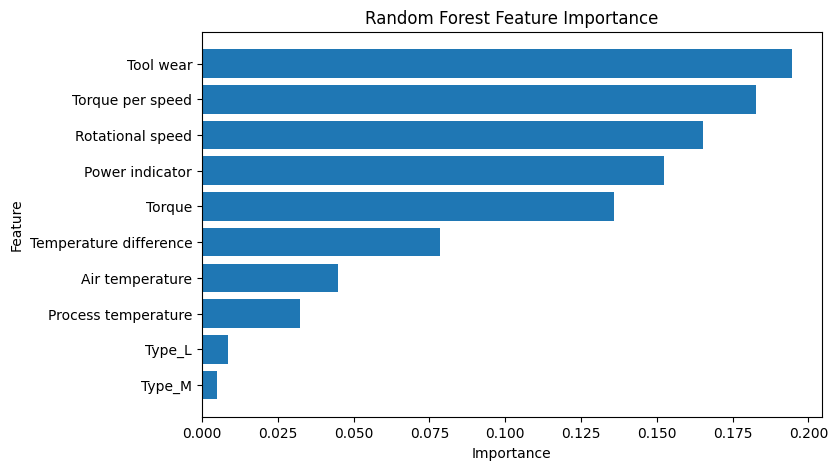

In [50]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## Feature Importance

Feature importance was used to understand which machine-condition variables contributed most to the Random Forest model's predictions. This improves model explainability and helps identify the key factors associated with machine failure.

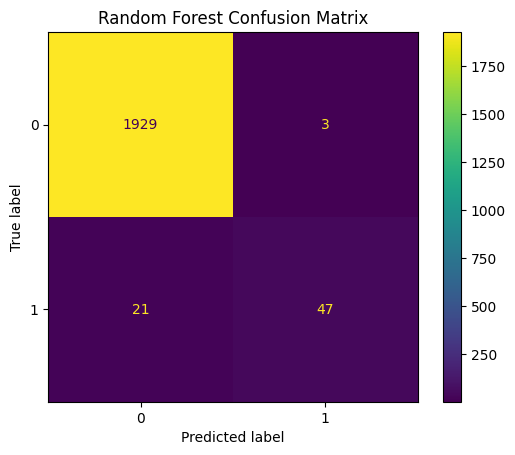

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest Confusion Matrix')
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows how many machine failures were correctly and incorrectly predicted. In predictive maintenance, false negatives are especially important because they represent actual machine failures that the model failed to detect.

In [52]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Prediction probabilities
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nLogistic Regression Average Precision:", average_precision_score(y_test, y_proba_log))
print("Random Forest Average Precision:", average_precision_score(y_test, y_proba_rf))

Logistic Regression ROC-AUC: 0.9344172451589332
Random Forest ROC-AUC: 0.9670525819023261

Logistic Regression Average Precision: 0.4546189483428329
Random Forest Average Precision: 0.8581229958492186


In [53]:
threshold_results = []

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1 Score': f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.1,0.504202,0.882353,0.641711
1,0.2,0.740260,0.838235,0.786207
2,0.3,0.888889,0.823529,0.854962
3,0.4,0.947368,0.794118,0.864000
4,0.5,0.940000,0.691176,0.796610


## Threshold Tuning

Threshold tuning was applied to the Random Forest model to improve failure detection. Since machine failures are rare but costly, lowering the prediction threshold can increase recall and help detect more actual failures, even if it creates more false alarms.

In [54]:
feature_importance
threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.1,0.504202,0.882353,0.641711
1,0.2,0.740260,0.838235,0.786207
2,0.3,0.888889,0.823529,0.854962
3,0.4,0.947368,0.794118,0.864000
4,0.5,0.940000,0.691176,0.796610


In [55]:
# Final threshold selected for Random Forest
final_threshold = 0.30

# Final predictions using selected threshold
y_pred_final = (y_proba_rf >= final_threshold).astype(int)

print("Final Random Forest Model with Threshold 0.30")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Final Random Forest Model with Threshold 0.30
Confusion Matrix:
[[1925    7]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.89      0.82      0.85        68

    accuracy                           0.99      2000
   macro avg       0.94      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000



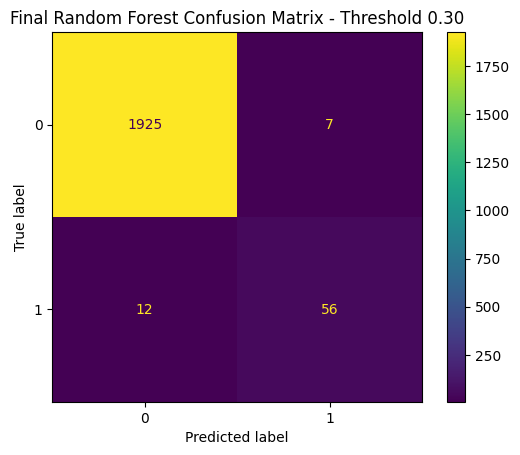

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
plt.title('Final Random Forest Confusion Matrix - Threshold 0.30')
plt.show()

In [57]:
final_model_results = pd.DataFrame({
    'Model': ['Random Forest - Default Threshold 0.50', 'Random Forest - Tuned Threshold 0.30'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_final)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_final)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_final)
    ]
})

final_model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Default Threshold 0.50,0.9880,0.940000,0.691176,0.796610
1,Random Forest - Tuned Threshold 0.30,0.9905,0.888889,0.823529,0.854962


## Final Model Selection

The Random Forest model was selected as the final model because it achieved strong precision, recall, and F1-score. Since predictive maintenance focuses on detecting possible machine failures before they occur, recall is very important. Therefore, the prediction threshold was adjusted from 0.50 to 0.30 to improve failure detection.

At threshold 0.30, the model achieved a better balance between precision and recall, making it more suitable for real-world maintenance decision support.

In [58]:
display(feature_importance)

,Feature,Importance
4,Tool wear,0.194696
7,Torque per speed,0.182541
2,Rotational speed,0.165100
6,Power indicator,0.152439
3,Torque,0.135851
5,Temperature difference,0.078477
0,Air temperature,0.045020
1,Process temperature,0.032292
8,Type_L,0.008658
9,Type_M,0.004927


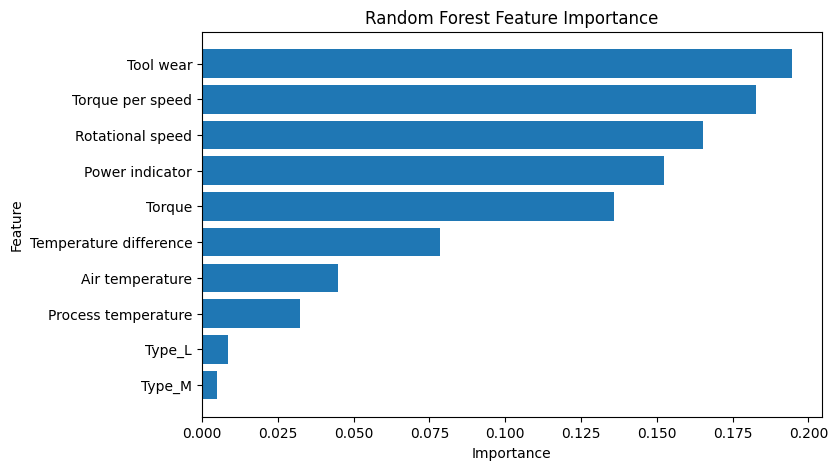

In [59]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [60]:
final_model_results
feature_importance

,Feature,Importance
4,Tool wear,0.194696
7,Torque per speed,0.182541
2,Rotational speed,0.165100
6,Power indicator,0.152439
3,Torque,0.135851
5,Temperature difference,0.078477
0,Air temperature,0.045020
1,Process temperature,0.032292
8,Type_L,0.008658
9,Type_M,0.004927


In [61]:
print("Final Model Results:")
display(final_model_results)

print("\nFeature Importance:")
display(feature_importance)

Final Model Results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Default Threshold 0.50,0.9880,0.940000,0.691176,0.796610
1,Random Forest - Tuned Threshold 0.30,0.9905,0.888889,0.823529,0.854962



Feature Importance:


,Feature,Importance
4,Tool wear,0.194696
7,Torque per speed,0.182541
2,Rotational speed,0.165100
6,Power indicator,0.152439
3,Torque,0.135851
5,Temperature difference,0.078477
0,Air temperature,0.045020
1,Process temperature,0.032292
8,Type_L,0.008658
9,Type_M,0.004927


## Feature Importance Interpretation

The Random Forest model identified tool wear as the most important feature for predicting machine failure. This indicates that machines with higher usage time are more likely to experience failure. Engineered features such as torque per speed and power indicator were also highly important, showing that machine load and operating intensity play a major role in failure prediction. Rotational speed and torque also contributed strongly to the model's decision-making process.

# Conclusion

This project developed a machine learning-based predictive maintenance model using industrial machine-condition data. The dataset was analyzed using exploratory data analysis, feature engineering, and classification models.

The analysis showed that failed machines generally had higher torque, higher tool wear, lower rotational speed, and higher power-related indicators compared to non-failed machines. New features such as temperature difference, power indicator, and torque per speed helped improve the understanding of machine operating conditions.

Two models were trained: Logistic Regression and Random Forest. Random Forest performed better overall. Since machine failures are rare but costly, threshold tuning was applied to improve failure detection. A threshold of 0.30 was selected because it provided a strong balance between precision and recall.

The final model can support predictive maintenance by identifying machines that are more likely to fail, allowing maintenance teams to take early action and reduce unexpected downtime.

In [62]:
import joblib

joblib.dump(rf_model, 'random_forest_predictive_maintenance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [64]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
import joblib

joblib.dump(rf_model, '/content/drive/MyDrive/random_forest_predictive_maintenance_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/scaler.pkl')

print("Model and scaler saved to Google Drive successfully.")

Model and scaler saved to Google Drive successfully.


In [66]:
### Simple prediction example
# Show one sample machine from the test data
sample_machine = X_test.iloc[0:1]

sample_machine


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Power indicator,Torque per speed,Type_L,Type_M
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,0.046617,True,False


In [67]:
# Predict failure probability for one sample machine
sample_probability = rf_model.predict_proba(sample_machine)[:, 1][0]

print("Failure probability:", sample_probability)

if sample_probability >= final_threshold:
    print("Prediction: Machine is at risk of failure")
else:
    print("Prediction: Machine is not at risk of failure")

Failure probability: 0.09
Prediction: Machine is not at risk of failure


In [68]:
final_model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Default Threshold 0.50,0.9880,0.940000,0.691176,0.796610
1,Random Forest - Tuned Threshold 0.30,0.9905,0.888889,0.823529,0.854962


## Final Model Result Interpretation

The tuned Random Forest model with a threshold of 0.30 performed better than the default threshold of 0.50. Although precision slightly decreased, recall improved from 69.11% to 82.35%, which means the model detected more actual machine failures.

In predictive maintenance, recall is very important because missing a real machine failure can lead to unexpected downtime and maintenance cost. Therefore, the Random Forest model with threshold 0.30 was selected as the final model.

In [69]:
import joblib
import json

# Save final Random Forest model
joblib.dump(rf_model, 'predictive_maintenance_random_forest_model.pkl')

# Save feature column names
with open('feature_columns.json', 'w') as file:
    json.dump(X.columns.tolist(), file)

# Save selected threshold
with open('final_threshold.json', 'w') as file:
    json.dump({'final_threshold': final_threshold}, file)

print("Final model, feature columns, and threshold saved successfully.")

Final model, feature columns, and threshold saved successfully.


In [70]:
import os

os.listdir()

['.config',
 'feature_columns.json',
 'scaler.pkl',
 'random_forest_predictive_maintenance_model.pkl',
 'predictive_maintenance_random_forest_model.pkl',
 'final_threshold.json',
 'drive',
 'sample_data']

In [73]:
def predict_machine_failure(machine_type, air_temp, process_temp, rotational_speed, torque, tool_wear):
    """
    Predicts whether a machine is at risk of failure.
    machine_type should be: 'H', 'L', or 'M'
    """

    # Create dataframe from input
    input_data = pd.DataFrame({
        'Air temperature': [air_temp],
        'Process temperature': [process_temp],
        'Rotational speed': [rotational_speed],
        'Torque': [torque],
        'Tool wear': [tool_wear]
    })

    # Feature engineering
    input_data['Temperature difference'] = input_data['Process temperature'] - input_data['Air temperature']
    input_data['Power indicator'] = input_data['Torque'] * input_data['Rotational speed']
    input_data['Torque per speed'] = input_data['Torque'] / input_data['Rotational speed']

    # Machine type encoding
    input_data['Type_L'] = 1 if machine_type == 'L' else 0
    input_data['Type_M'] = 1 if machine_type == 'M' else 0

    # Arrange columns in same order as training data
    input_data = input_data[X.columns]

    # Predict probability
    failure_probability = rf_model.predict_proba(input_data)[:, 1][0]

    # Apply selected threshold
    if failure_probability >= final_threshold:
        prediction = "Machine is at risk of failure"
    else:
        prediction = "Machine is not at risk of failure"

    return failure_probability, prediction

In [74]:
probability, prediction = predict_machine_failure(
    machine_type='L',
    air_temp=300,
    process_temp=310,
    rotational_speed=1400,
    torque=55,
    tool_wear=180
)

print("Failure Probability:", probability)
print("Prediction:", prediction)

Failure Probability: 0.02
Prediction: Machine is not at risk of failure


In [75]:
# Create test results dataframe

test_results = X_test.copy()
test_results['Actual Machine Failure'] = y_test.values
test_results['Predicted Failure Probability'] = y_proba_rf
test_results['Predicted Machine Failure'] = y_pred_final

test_results.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Power indicator,Torque per speed,Type_L,Type_M,Actual Machine Failure,Predicted Failure Probability,Predicted Machine Failure
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,0.046617,True,False,0,0.09,0
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,0.026504,True,False,0,0.00,0
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,0.024118,True,False,0,0.09,0
951,295.6,306.3,1509,35.8,60,10.7,54022.2,0.023724,False,False,0,0.01,0
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,0.044477,False,False,0,0.06,0


In [76]:
test_results.to_csv('predictive_maintenance_test_results.csv', index=False)

print("Test prediction results saved successfully.")

Test prediction results saved successfully.


In [77]:
from google.colab import files

files.download('predictive_maintenance_random_forest_model.pkl')
files.download('feature_columns.json')
files.download('final_threshold.json')
files.download('predictive_maintenance_test_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Practical Use of the Model

A prediction function was created to estimate the failure risk of a new machine based on operating conditions such as temperature, rotational speed, torque, tool wear, and machine type. The model returns a failure probability and classifies the machine as either at risk or not at risk using the selected threshold of 0.30.

This demonstrates how the trained model can be used as a decision-support tool for predictive maintenance.

In [78]:
# Find one actual failed machine from the test set
failed_machine_index = y_test[y_test == 1].index[0]

# Get that machine's input values
real_failed_machine = X_test.loc[[failed_machine_index]]

# Predict failure probability
real_failed_probability = rf_model.predict_proba(real_failed_machine)[:, 1][0]

print("Actual Machine Failure:", y_test.loc[failed_machine_index])
print("Predicted Failure Probability:", real_failed_probability)

if real_failed_probability >= final_threshold:
    print("Prediction: Machine is at risk of failure")
else:
    print("Prediction: Machine is not at risk of failure")

display(real_failed_machine)

Actual Machine Failure: 1
Predicted Failure Probability: 0.48
Prediction: Machine is at risk of failure


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Power indicator,Torque per speed,Type_L,Type_M
4851,303.7,312.1,1363,51.8,90,8.4,70603.4,0.038004,True,False


In [79]:
test_results = X_test.copy()

test_results['Actual Machine Failure'] = y_test.values
test_results['Predicted Failure Probability'] = y_proba_rf
test_results['Predicted Machine Failure'] = y_pred_final

test_results.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Power indicator,Torque per speed,Type_L,Type_M,Actual Machine Failure,Predicted Failure Probability,Predicted Machine Failure
2997,300.5,309.8,1345,62.7,153,9.3,84331.5,0.046617,True,False,0,0.09,0
4871,303.7,312.4,1513,40.1,135,8.7,60671.3,0.026504,True,False,0,0.00,0
3858,302.5,311.4,1559,37.6,209,8.9,58618.4,0.024118,True,False,0,0.09,0
951,295.6,306.3,1509,35.8,60,10.7,54022.2,0.023724,False,False,0,0.01,0
6463,300.5,310.0,1358,60.4,102,9.5,82023.2,0.044477,False,False,0,0.06,0


In [80]:
test_results.to_csv('predictive_maintenance_test_results.csv', index=False)

print("Test prediction results saved successfully.")

Test prediction results saved successfully.


In [81]:
from google.colab import files

files.download('predictive_maintenance_random_forest_model.pkl')
files.download('feature_columns.json')
files.download('final_threshold.json')
files.download('predictive_maintenance_test_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>